# Train LightGB

### Imports

In [ ]:
import pandas as pd
import numpy as np
from datetime import date
from pathlib import Path
import os
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

%matplotlib inline
import matplotlib.pyplot as plt

import seaborn as sns

from data_preparation.preprocessed import main_preprocessed

c:\Users\bapti\Documents\INSA\CHALLENGE\M1_Challenge_St_Exupery\scripts\training\add_features.py:17: SyntaxWarning: invalid escape sequence '\)'
  - Global ones ? (/!\) Data leakage risk, to be used with caution and only if they are based on historical data (ex: median of the last 30 days for this airline, etc.)


### Global variables

In [3]:
root = Path(os.getcwd()).parent.parent
DATA_PATH = os.path.join(root, "data")
# DATASET_PATH = os.path.join(DATA_PATH, "main.csv")
DATASET_PATH = os.path.join(DATA_PATH, "main_preprocessed.csv")

TARGET = "NbPaxTotal"

LIMIT_DATE_TRAIN = pd.Timestamp("2025-12-31")
LIMIT_DATE_VALID = pd.Timestamp("2026-01-30")

### Load and prepare data

In [4]:
df = pd.read_csv(DATASET_PATH)
df['LTScheduledDatetime'] = pd.to_datetime(df['LTScheduledDatetime'])

# df = add_features(df)
# df.to_csv("main_preprocessed.csv", index=False)

train_df = df[df['LTScheduledDatetime'] < LIMIT_DATE_TRAIN].copy()
valid_df = df[(df['LTScheduledDatetime'] >= LIMIT_DATE_TRAIN) & (df['LTScheduledDatetime'] < LIMIT_DATE_VALID)].copy()

print(f"Train set: {len(train_df)} rows / From {train_df['LTScheduledDatetime'].min()} to {train_df['LTScheduledDatetime'].max()}")
print(f"Valid set: {len(valid_df)} rows / From {valid_df['LTScheduledDatetime'].min()} to {valid_df['LTScheduledDatetime'].max()}")

X_train = train_df.drop(columns=[TARGET, "LTScheduledDatetime"])
y_train = train_df[TARGET]
X_valid = valid_df.drop(columns=[TARGET, "LTScheduledDatetime"])
y_valid = valid_df[TARGET]

for col in X_train.select_dtypes(include=['object']).columns:
    X_train[col] = X_train[col].astype('category')
    X_valid[col] = X_valid[col].astype('category')


C:\Users\bapti\AppData\Local\Temp\ipykernel_23692\1495111035.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATASET_PATH)


Train set: 286749 rows / From 2023-01-01 00:05:00 to 2025-12-30 23:55:00
Valid set: 7349 rows / From 2025-12-31 00:20:00 to 2026-01-29 23:45:00


In [6]:
print(df.shape)
l = df.columns
print(l)

(365005, 1076)
Index(['IdMovement', 'IdADL', 'IdAircraftType', 'IdBusinessUnitType',
       'IdBusContactType', 'IdTerminalType', 'IdBagStatusDelivery', 'NbFlight',
       'AirportCode', 'airlineOACICode',
       ...
       'INT_NbOfSeats_x_Direction_trend_91D_vs_182D_mean',
       'INT_NbOfSeats_x_Direction_trend_182D_vs_365D_mean',
       'INT_NbOfSeats_x_Direction_trend_14D_vs_30D_mean',
       'INT_NbOfSeats_x_Direction_trend_30D_vs_91D_mean',
       'INT_NbOfSeats_x_Direction_trend_7D_vs_14D_mean',
       'INT_NbOfSeats_x_MOM_Direction_rolling_week_mean_accel_rolling_month',
       'INT_NbOfSeats_x_MOM_Direction_rolling_month_mean_month_ratio_rolling_quarter',
       'INT_NbOfSeats_x_MOM_Direction_rolling_quarter_mean_season_ratio_rolling_year',
       'INT_NbOfSeats_x_MOM_Direction_lag91_win20_mean_year_over_year_lag365_win28',
       'INT_NbOfSeats_x_MOM_Direction_lag30_win14_mean_short_vs_mid_hist_lag91_win20'],
      dtype='object', length=1076)


In [ ]:
### Remove the less important features.
# this feature_importance.csv dataset is obtained by training the model once with all the features . Here to save time, we first remove the useless features to test the model performances with the new set of features.
importance = pd.read_csv(os.path.join(DATA_PATH, 'feature_importance.csv'), encoding='utf-8')
col_to_rmv_list = importance["feature"].tail(500).tolist()

df = df.drop(columns=col_to_rmv_list)

KeyError: "['airlineOACICode_lag30_win14_max', 'Direction', 'Direction_trend_182D_vs_365D_max', 'INT_NbOfSeats_x_IdAircraftType_lag_3months_mean', 'INT_NbOfSeats_x_IdAircraftType_lag91_win20_mean', 'INT_NbOfSeats_x_airlineOACICode_lag182_win20_mean', 'SysTerminal_lag365_win28_median', 'airlineOACICode_rolling_semester_min', 'INT_NbOfSeats_x_airlineOACICode_lag_3months_mean', 'Direction_lag_1month_median', 'INT_NbOfSeats_x_airlineOACICode_lag91_win20_mean', 'FlightNumberNormalized_trend_91D_vs_182D_max', 'FlightNumberNormalized_lag365_win28_std', 'IdAircraftType_trend_91D_vs_182D_max', 'SysTerminal_rolling_semester_median', 'SysTerminal_lag365_win28_max', 'SysTerminal_lag_3months_median', 'MOM_Direction_lag91_win20_median_year_over_year_lag365_win28', 'INT_NbOfSeats_x_IdAircraftType_lag30_win14_mean', 'Direction_trend_91D_vs_182D_max', 'INT_NbOfSeats_x_MOM_FlightNumberNormalized_rolling_month_mean_month_ratio_rolling_quarter', 'IdAircraftType_lag_1month_std', 'FlightNumberNormalized_lag365_win28_median', 'MOM_IdAircraftType_rolling_week_mean_accel_rolling_month.1', 'IdAircraftType_rolling_quarter_min', 'MOM_FlightNumberNormalized_rolling_quarter_std_season_ratio_rolling_year.1', 'MOM_IdAircraftType_lag30_win14_std_short_vs_mid_hist_lag91_win20', 'Direction_lag365_win28_max', 'IdAircraftType_lag_1month_max', 'IdAircraftType_lag30_win14_min', 'MOM_airlineOACICode_rolling_month_median_month_ratio_rolling_quarter', 'MOM_airlineOACICode_lag30_win14_std_short_vs_mid_hist_lag91_win20', 'MOM_SysTerminal_rolling_month_median_month_ratio_rolling_quarter', 'MOM_IdAircraftType_rolling_month_mean_month_ratio_rolling_quarter', 'FlightNumberNormalized_trend_182D_vs_365D_max', 'Direction_rolling_semester_median', 'MOM_Direction_rolling_month_median_month_ratio_rolling_quarter', 'airlineOACICode_rolling_year_min', 'FuelProvider', 'airlineOACICode_trend_91D_vs_182D_max', 'airlineOACICode_lag182_win20_median', 'MOM_airlineOACICode_rolling_week_std_accel_rolling_month.1', 'MOM_IdAircraftType_rolling_month_median_month_ratio_rolling_quarter', 'airlineOACICode_lag182_win20_max', 'IdAircraftType_lag_6months_max', 'MOM_airlineOACICode_rolling_week_mean_accel_rolling_month.1', 'sin_Minute', 'IdAircraftType_lag_1day_median', 'IdAircraftType_lag_1year_mean', 'IdAircraftType_lag_3months_max', 'FlightNumberNormalized_lag_3months_mean', 'MOM_IdAircraftType_rolling_week_std_accel_rolling_month.1', 'IdAircraftType_lag182_win20_max', 'MOM_airlineOACICode_lag91_win20_mean_year_over_year_lag365_win28', 'airlineOACICode_lag_3months_mean', 'airlineOACICode_lag365_win28_std', 'IdAircraftType_lag_3months_min', 'FlightNumberNormalized_lag91_win20_median', 'Direction_lag_1year_min', 'INT_NbOfSeats_x_airlineOACICode_lag_1month_mean', 'FlightNumberNormalized_trend_91D_vs_182D_min', 'IdAircraftType_lag365_win28_median', 'FlightNumberNormalized_lag182_win20_max', 'airlineOACICode_lag365_win28_mean', 'MOM_FlightNumberNormalized_rolling_quarter_median_season_ratio_rolling_year.1', 'MOM_Direction_rolling_month_std_month_ratio_rolling_quarter', 'INT_NbOfSeats_x_MOM_airlineOACICode_rolling_month_mean_month_ratio_rolling_quarter', 'airlineOACICode_lag_1year_mean', 'INT_NbOfSeats_x_IdAircraftType_lag365_win28_mean', 'airlineOACICode_trend_30D_vs_91D_min', 'MOM_airlineOACICode_rolling_quarter_mean_season_ratio_rolling_year.1', 'IdAircraftType_lag182_win20_median', 'MOM_SysTerminal_lag91_win20_median_year_over_year_lag365_win28', 'Direction_lag_6months_median', 'MOM_FlightNumberNormalized_rolling_week_median_accel_rolling_month.2', 'INT_NbOfSeats_x_FlightNumberNormalized_lag30_win14_mean', 'MOM_airlineOACICode_rolling_week_min_accel_rolling_month.1', 'SysTerminal_lag7_win6_min', 'MOM_airlineOACICode_rolling_month_std_month_ratio_rolling_quarter', 'MOM_IdAircraftType_lag30_win14_max_short_vs_mid_hist_lag91_win20', 'airlineOACICode_lag182_win20_min', 'MOM_FlightNumberNormalized_rolling_quarter_mean_season_ratio_rolling_year.1', 'airlineOACICode_lag_1month_min', 'airlineOACICode_lag365_win28_max', 'MOM_FlightNumberNormalized_rolling_month_std_month_ratio_rolling_quarter', 'MOM_IdAircraftType_rolling_week_max_accel_rolling_month.1', 'SysTerminal_rolling_month_median', 'IdAircraftType_lag365_win28_mean', 'MOM_airlineOACICode_rolling_month_mean_month_ratio_rolling_quarter', 'IdAircraftType_lag365_win28_std', 'MOM_airlineOACICode_rolling_quarter_std_season_ratio_rolling_year.1', 'Direction_rolling_year_median', 'airlineOACICode_lag_1day_std', 'IdAircraftType_lag_6months_min', 'MOM_IdAircraftType_lag30_win14_median_short_vs_mid_hist_lag91_win20', 'Direction_lag365_win28_median', 'INT_NbOfSeats_x_MOM_SysTerminal_rolling_month_mean_month_ratio_rolling_quarter', 'IdAircraftType_lag91_win20_max', 'MOM_SysTerminal_rolling_week_median_accel_rolling_month.1', 'FlightNumberNormalized_lag365_win28_mean', 'MOM_FlightNumberNormalized_lag30_win14_mean_short_vs_mid_hist_lag91_win20', 'MOM_IdAircraftType_rolling_month_std_month_ratio_rolling_quarter', 'SysTerminal_rolling_month_min', 'MOM_SysTerminal_lag30_win14_mean_short_vs_mid_hist_lag91_win20.1', 'MOM_FlightNumberNormalized_lag91_win20_median_year_over_year_lag365_win28', 'MOM_airlineOACICode_lag30_win14_max_short_vs_mid_hist_lag91_win20', 'Direction_lag_3months_median', 'MOM_Direction_lag91_win20_max_year_over_year_lag365_win28', 'SysTerminal_trend_7D_vs_14D_min', 'airlineOACICode_lag_6months_mean', 'INT_NbOfSeats_x_MOM_IdAircraftType_rolling_month_mean_month_ratio_rolling_quarter', 'MOM_Direction_rolling_month_max_month_ratio_rolling_quarter', 'INT_NbOfSeats_x_airlineOACICode_lag_6months_mean', 'MOM_FlightNumberNormalized_rolling_month_median_month_ratio_rolling_quarter.1', 'MOM_FlightNumberNormalized_rolling_week_mean_accel_rolling_month.2', 'FlightNumberNormalized_lag_6months_mean', 'INT_NbOfSeats_x_airlineOACICode_lag_1year_mean', 'MOM_Direction_rolling_month_mean_month_ratio_rolling_quarter', 'MOM_FlightNumberNormalized_lag30_win14_median_short_vs_mid_hist_lag91_win20', 'INT_NbOfSeats_x_FlightNumberNormalized_lag_3months_mean', 'MOM_FlightNumberNormalized_rolling_month_max_month_ratio_rolling_quarter', 'MOM_FlightNumberNormalized_rolling_month_min_month_ratio_rolling_quarter', 'MOM_FlightNumberNormalized_lag30_win14_min_short_vs_mid_hist_lag91_win20', 'airlineOACICode_lag30_win14_min', 'MOM_IdAircraftType_lag91_win20_max_year_over_year_lag365_win28', 'MOM_SysTerminal_rolling_week_mean_accel_rolling_month.1', 'MOM_FlightNumberNormalized_lag30_win14_std_short_vs_mid_hist_lag91_win20', 'MOM_SysTerminal_rolling_week_std_accel_rolling_month.1', 'FlightNumberNormalized_lag91_win20_max', 'MOM_SysTerminal_rolling_month_std_month_ratio_rolling_quarter', 'SysTerminal_lag_1year_median', 'MOM_IdAircraftType_lag30_win14_min_short_vs_mid_hist_lag91_win20', 'SysTerminal_lag_6months_median', 'MOM_FlightNumberNormalized_lag30_win14_max_short_vs_mid_hist_lag91_win20', 'MOM_IdAircraftType_rolling_quarter_mean_season_ratio_rolling_year.1', 'airlineOACICode_lag_1day_median', 'IdAircraftType_lag_1year_min', 'MOM_FlightNumberNormalized_rolling_week_max_accel_rolling_month.1', 'IdAircraftType_rolling_year_min', 'MOM_airlineOACICode_rolling_quarter_median_season_ratio_rolling_year.1', 'MOM_IdAircraftType_rolling_quarter_std_season_ratio_rolling_year.1', 'MOM_SysTerminal_lag30_win14_median_short_vs_mid_hist_lag91_win20.1', 'FlightNumberNormalized_lag365_win28_max', 'airlineOACICode_lag_1month_max', 'INT_NbOfSeats_x_MOM_Direction_rolling_month_mean_month_ratio_rolling_quarter', 'FlightNumberNormalized_lag_1month_min', 'sin_Month', 'MOM_IdAircraftType_rolling_week_min_accel_rolling_month', 'IdAircraftType_trend_14D_vs_30D_min', 'MOM_SysTerminal_rolling_month_mean_month_ratio_rolling_quarter', 'INT_NbOfSeats_x_IdAircraftType_lag_1year_mean', 'MOM_airlineOACICode_lag30_win14_median_short_vs_mid_hist_lag91_win20', 'MOM_SysTerminal_rolling_week_max_accel_rolling_month.1', 'MOM_SysTerminal_lag30_win14_std_short_vs_mid_hist_lag91_win20.1', 'MOM_IdAircraftType_rolling_quarter_median_season_ratio_rolling_year.1', 'IdAircraftType_trend_30D_vs_91D_min', 'INT_NbOfSeats_x_airlineOACICode_lag365_win28_mean', 'airlineOACICode_lag91_win20_min', 'MOM_FlightNumberNormalized_rolling_quarter_min_season_ratio_rolling_year.1', 'airlineOACICode_lag_1year_max', 'IdAircraftType_rolling_semester_min', 'MOM_SysTerminal_rolling_quarter_mean_season_ratio_rolling_year.1', 'FlightNumberNormalized_lag_1week_median', 'MOM_SysTerminal_lag91_win20_mean_year_over_year_lag365_win28.1', 'INT_NbOfSeats_x_FlightNumberNormalized_lag365_win28_mean', 'MOM_airlineOACICode_rolling_month_max_month_ratio_rolling_quarter', 'Direction_lag_1year_median', 'FlightNumberNormalized_lag_1year_min', 'MOM_SysTerminal_lag30_win14_max_short_vs_mid_hist_lag91_win20.1', 'SysTerminal_trend_91D_vs_182D_max', 'MOM_SysTerminal_lag91_win20_std_year_over_year_lag365_win28.1', 'MOM_airlineOACICode_rolling_quarter_max_season_ratio_rolling_year.1', 'ScheduleType', 'MOM_airlineOACICode_lag30_win14_mean_short_vs_mid_hist_lag91_win20', 'INT_NbOfSeats_x_FlightNumberNormalized_lag_6months_mean', 'SysTerminal_rolling_year_median', 'MOM_FlightNumberNormalized_rolling_quarter_max_season_ratio_rolling_year.1', 'airlineOACICode_lag_6months_min', 'MOM_IdAircraftType_lag91_win20_std_year_over_year_lag365_win28', 'MOM_SysTerminal_lag30_win14_min_short_vs_mid_hist_lag91_win20', 'MOM_airlineOACICode_lag91_win20_median_year_over_year_lag365_win28', 'MOM_SysTerminal_rolling_quarter_median_season_ratio_rolling_year.1', 'MOM_IdAircraftType_rolling_week_mean_accel_rolling_month.2', 'IdAircraftType_lag_1year_max', 'MOM_airlineOACICode_lag91_win20_std_year_over_year_lag365_win28', 'airlineOACICode_lag_3months_max', 'MOM_SysTerminal_rolling_quarter_std_season_ratio_rolling_year.1', 'MOM_airlineOACICode_lag30_win14_min_short_vs_mid_hist_lag91_win20', 'airlineOACICode_lag_3months_min', 'airlineOACICode_trend_91D_vs_182D_min', 'MOM_FlightNumberNormalized_lag91_win20_mean_year_over_year_lag365_win28', 'MOM_airlineOACICode_rolling_quarter_std_season_ratio_rolling_year.2', 'etl_origin', 'MOM_FlightNumberNormalized_lag91_win20_std_year_over_year_lag365_win28', 'IdAircraftType_lag_1month_median', 'MOM_airlineOACICode_rolling_week_median_accel_rolling_month.2', 'MOM_IdAircraftType_lag30_win14_mean_short_vs_mid_hist_lag91_win20.1', 'IdAircraftType_lag365_win28_max', 'IdAircraftType_lag_6months_std', 'MOM_IdAircraftType_rolling_month_max_month_ratio_rolling_quarter', 'MOM_SysTerminal_lag91_win20_median_year_over_year_lag365_win28.1', 'FlightNumberNormalized_lag365_win28_min', 'MOM_IdAircraftType_lag91_win20_median_year_over_year_lag365_win28', 'MOM_IdAircraftType_rolling_week_std_accel_rolling_month.2', 'MOM_FlightNumberNormalized_rolling_quarter_median_season_ratio_rolling_year.2', 'FlightNumberNormalized_lag_1day_median', 'MOM_SysTerminal_rolling_week_min_accel_rolling_month', 'INT_NbOfSeats_x_FlightNumberNormalized_lag_1year_mean', 'MOM_airlineOACICode_rolling_week_max_accel_rolling_month.1', 'MOM_FlightNumberNormalized_rolling_month_median_month_ratio_rolling_quarter.2', 'SysTerminal_trend_182D_vs_365D_max', 'MOM_airlineOACICode_lag30_win14_std_short_vs_mid_hist_lag91_win20.1', 'MOM_IdAircraftType_rolling_month_std_month_ratio_rolling_quarter.1', 'MOM_airlineOACICode_rolling_month_median_month_ratio_rolling_quarter.1', 'MOM_IdAircraftType_rolling_month_median_month_ratio_rolling_quarter.1', 'MOM_SysTerminal_rolling_month_max_month_ratio_rolling_quarter', 'MOM_airlineOACICode_rolling_month_mean_month_ratio_rolling_quarter.1', 'airlineOACICode_lag_6months_max', 'MOM_FlightNumberNormalized_lag91_win20_max_year_over_year_lag365_win28', 'MOM_FlightNumberNormalized_rolling_month_std_month_ratio_rolling_quarter.1', 'MOM_IdAircraftType_rolling_quarter_max_season_ratio_rolling_year.1', 'MOM_IdAircraftType_lag30_win14_max_short_vs_mid_hist_lag91_win20.1', 'MOM_IdAircraftType_rolling_week_median_accel_rolling_month.2', 'MOM_IdAircraftType_lag30_win14_std_short_vs_mid_hist_lag91_win20.1', 'airlineOACICode_lag_1year_min', 'MOM_airlineOACICode_lag91_win20_min_year_over_year_lag365_win28', 'FlightNumberNormalized_lag_3months_min', 'Quarter', 'MOM_FlightNumberNormalized_lag30_win14_min_short_vs_mid_hist_lag91_win20.1', 'MOM_FlightNumberNormalized_rolling_week_std_accel_rolling_month.2', 'FlightNumberNormalized_lag_6months_min', 'FlightNumberNormalized_lag_1week_std', 'MOM_IdAircraftType_lag30_win14_median_short_vs_mid_hist_lag91_win20.1', 'MOM_airlineOACICode_lag91_win20_median_year_over_year_lag365_win28.1', 'MOM_FlightNumberNormalized_rolling_month_min_month_ratio_rolling_quarter.1', 'MOM_airlineOACICode_lag91_win20_max_year_over_year_lag365_win28', 'MOM_IdAircraftType_rolling_month_mean_month_ratio_rolling_quarter.1', 'MOM_FlightNumberNormalized_lag30_win14_median_short_vs_mid_hist_lag91_win20.1', 'MOM_airlineOACICode_rolling_month_min_month_ratio_rolling_quarter', 'MOM_SysTerminal_rolling_month_median_month_ratio_rolling_quarter.1', 'MOM_IdAircraftType_rolling_week_max_accel_rolling_month.2', 'IdAircraftType_lag91_win20_min', 'MOM_IdAircraftType_lag91_win20_mean_year_over_year_lag365_win28', 'IdAircraftType_lag365_win28_min', 'MOM_FlightNumberNormalized_lag91_win20_median_year_over_year_lag365_win28.1', 'MOM_FlightNumberNormalized_rolling_quarter_mean_season_ratio_rolling_year.2', 'SysTerminal_lag182_win20_min', 'MOM_airlineOACICode_rolling_week_mean_accel_rolling_month.2', 'MOM_FlightNumberNormalized_rolling_week_min_accel_rolling_month.2', 'MOM_SysTerminal_rolling_week_min_accel_rolling_month.1', 'MOM_SysTerminal_rolling_month_mean_month_ratio_rolling_quarter.1', 'MOM_IdAircraftType_rolling_week_min_accel_rolling_month.1', 'MOM_airlineOACICode_rolling_month_std_month_ratio_rolling_quarter.1', 'MOM_airlineOACICode_lag91_win20_mean_year_over_year_lag365_win28.1', 'MOM_airlineOACICode_rolling_quarter_mean_season_ratio_rolling_year.2', 'MOM_IdAircraftType_lag91_win20_std_year_over_year_lag365_win28.1', 'IdAircraftType_lag_1year_median', 'MOM_FlightNumberNormalized_rolling_month_mean_month_ratio_rolling_quarter.2', 'IdAircraftType_lag_1year_std', 'MOM_IdAircraftType_lag91_win20_max_year_over_year_lag365_win28.1', 'MOM_FlightNumberNormalized_lag30_win14_mean_short_vs_mid_hist_lag91_win20.1', 'SysTerminal_rolling_quarter_min', 'SysTerminal_lag30_win14_min', 'MOM_SysTerminal_rolling_month_std_month_ratio_rolling_quarter.1', 'airlineOACICode_lag_3months_std', 'MOM_IdAircraftType_rolling_month_min_month_ratio_rolling_quarter', 'MOM_FlightNumberNormalized_lag91_win20_min_year_over_year_lag365_win28', 'MOM_FlightNumberNormalized_rolling_week_max_accel_rolling_month.2', 'airlineOACICode_trend_182D_vs_365D_min', 'MOM_IdAircraftType_rolling_quarter_mean_season_ratio_rolling_year.2', 'MOM_SysTerminal_rolling_quarter_max_season_ratio_rolling_year.1', 'MOM_FlightNumberNormalized_rolling_week_std_accel_rolling_month.3', 'Year', 'MOM_IdAircraftType_rolling_month_max_month_ratio_rolling_quarter.2', 'airlineOACICode_lag365_win28_min', 'MOM_FlightNumberNormalized_rolling_month_std_month_ratio_rolling_quarter.2', 'airlineOACICode_lag_1year_median', 'MOM_FlightNumberNormalized_rolling_week_median_accel_rolling_month.3', 'IdAircraftType_lag_6months_median', 'MOM_airlineOACICode_rolling_week_std_accel_rolling_month.2', 'MOM_airlineOACICode_rolling_week_min_accel_rolling_month.2', 'MOM_FlightNumberNormalized_rolling_week_mean_accel_rolling_month.3', 'MOM_FlightNumberNormalized_rolling_quarter_max_season_ratio_rolling_year.2', 'MOM_FlightNumberNormalized_lag30_win14_max_short_vs_mid_hist_lag91_win20.1', 'MOM_FlightNumberNormalized_lag91_win20_max_year_over_year_lag365_win28.1', 'MOM_airlineOACICode_lag91_win20_std_year_over_year_lag365_win28.2', 'MOM_IdAircraftType_lag30_win14_mean_short_vs_mid_hist_lag91_win20.2', 'MOM_SysTerminal_lag91_win20_max_year_over_year_lag365_win28.1', 'MOM_FlightNumberNormalized_lag91_win20_std_year_over_year_lag365_win28.1', 'MOM_airlineOACICode_lag91_win20_min_year_over_year_lag365_win28.1', 'MOM_airlineOACICode_rolling_week_median_accel_rolling_month.3', 'MOM_airlineOACICode_rolling_week_std_accel_rolling_month.3', 'MOM_airlineOACICode_rolling_quarter_max_season_ratio_rolling_year.2', 'SysTerminal_lag91_win20_min', 'MOM_airlineOACICode_rolling_month_max_month_ratio_rolling_quarter.1', 'MOM_FlightNumberNormalized_rolling_quarter_std_season_ratio_rolling_year.2', 'MOM_IdAircraftType_rolling_month_median_month_ratio_rolling_quarter.2', 'MOM_FlightNumberNormalized_lag91_win20_min_year_over_year_lag365_win28.1', 'MOM_IdAircraftType_rolling_quarter_median_season_ratio_rolling_year.2', 'MOM_IdAircraftType_lag91_win20_median_year_over_year_lag365_win28.1', 'FlightNumberNormalized_lag_1year_median', 'MOM_airlineOACICode_lag30_win14_mean_short_vs_mid_hist_lag91_win20.1', 'IdAircraftType_lag_3months_median', 'IdAircraftType_lag182_win20_min', 'airlineOACICode_lag_1year_std', 'MOM_FlightNumberNormalized_lag30_win14_median_short_vs_mid_hist_lag91_win20.2', 'MOM_airlineOACICode_lag30_win14_median_short_vs_mid_hist_lag91_win20.1', 'MOM_FlightNumberNormalized_rolling_month_mean_month_ratio_rolling_quarter.1', 'MOM_FlightNumberNormalized_rolling_quarter_median_season_ratio_rolling_year.3', 'MOM_airlineOACICode_lag91_win20_mean_year_over_year_lag365_win28.2', 'MOM_IdAircraftType_rolling_month_max_month_ratio_rolling_quarter.1', 'MOM_FlightNumberNormalized_rolling_month_median_month_ratio_rolling_quarter.3', 'MOM_IdAircraftType_lag30_win14_min_short_vs_mid_hist_lag91_win20.1', 'MOM_airlineOACICode_rolling_week_min_accel_rolling_month.3', 'MOM_SysTerminal_lag30_win14_min_short_vs_mid_hist_lag91_win20.1', 'MOM_airlineOACICode_rolling_quarter_median_season_ratio_rolling_year.2', 'MOM_FlightNumberNormalized_rolling_quarter_mean_season_ratio_rolling_year.3', 'airlineOACICode_lag_1month_median', 'MOM_IdAircraftType_rolling_quarter_std_season_ratio_rolling_year.2', 'MOM_IdAircraftType_rolling_month_mean_month_ratio_rolling_quarter.2', 'MOM_airlineOACICode_lag30_win14_max_short_vs_mid_hist_lag91_win20.2', 'MOM_airlineOACICode_lag91_win20_std_year_over_year_lag365_win28.1', 'MOM_FlightNumberNormalized_lag91_win20_median_year_over_year_lag365_win28.2', 'MOM_FlightNumberNormalized_lag91_win20_std_year_over_year_lag365_win28.2', 'MOM_FlightNumberNormalized_lag91_win20_mean_year_over_year_lag365_win28.1', 'SysTerminal_trend_14D_vs_30D_min', 'Semester', 'MOM_FlightNumberNormalized_rolling_quarter_min_season_ratio_rolling_year.2', 'MOM_airlineOACICode_rolling_week_max_accel_rolling_month.2', 'MOM_IdAircraftType_lag91_win20_median_year_over_year_lag365_win28.2', 'MOM_airlineOACICode_rolling_week_mean_accel_rolling_month.3', 'MOM_IdAircraftType_rolling_week_min_accel_rolling_month.2', 'MOM_IdAircraftType_lag30_win14_median_short_vs_mid_hist_lag91_win20.2', 'MOM_airlineOACICode_lag30_win14_min_short_vs_mid_hist_lag91_win20.2', 'MOM_airlineOACICode_lag30_win14_std_short_vs_mid_hist_lag91_win20.2', 'MOM_IdAircraftType_lag30_win14_min_short_vs_mid_hist_lag91_win20.2', 'MOM_IdAircraftType_lag30_win14_std_short_vs_mid_hist_lag91_win20.2', 'MOM_airlineOACICode_lag30_win14_max_short_vs_mid_hist_lag91_win20.3', 'MOM_airlineOACICode_lag30_win14_std_short_vs_mid_hist_lag91_win20.3', 'MOM_IdAircraftType_lag30_win14_max_short_vs_mid_hist_lag91_win20.2', 'MOM_airlineOACICode_lag30_win14_mean_short_vs_mid_hist_lag91_win20.2', 'MOM_IdAircraftType_lag91_win20_mean_year_over_year_lag365_win28.1', 'MOM_IdAircraftType_lag91_win20_min_year_over_year_lag365_win28.1', 'MOM_airlineOACICode_lag91_win20_min_year_over_year_lag365_win28.2', 'FlightNumberNormalized_lag_1month_max', 'MOM_FlightNumberNormalized_lag91_win20_max_year_over_year_lag365_win28.2', 'FlightNumberNormalized_lag_3months_median', 'FlightNumberNormalized_lag_3months_max', 'MOM_FlightNumberNormalized_rolling_week_min_accel_rolling_month.3', 'MOM_airlineOACICode_rolling_month_max_month_ratio_rolling_quarter.2', 'MOM_FlightNumberNormalized_rolling_week_max_accel_rolling_month.3', 'MOM_airlineOACICode_rolling_month_mean_month_ratio_rolling_quarter.2', 'MOM_FlightNumberNormalized_rolling_month_mean_month_ratio_rolling_quarter.3', 'MOM_airlineOACICode_rolling_month_std_month_ratio_rolling_quarter.2', 'MOM_FlightNumberNormalized_rolling_quarter_std_season_ratio_rolling_year.3', 'MOM_airlineOACICode_lag91_win20_median_year_over_year_lag365_win28.2', 'MOM_airlineOACICode_lag30_win14_min_short_vs_mid_hist_lag91_win20.1', 'MOM_FlightNumberNormalized_lag30_win14_std_short_vs_mid_hist_lag91_win20.2', 'MOM_airlineOACICode_lag30_win14_max_short_vs_mid_hist_lag91_win20.1', 'MOM_FlightNumberNormalized_rolling_week_std_accel_rolling_month.4', 'MOM_airlineOACICode_rolling_month_max_month_ratio_rolling_quarter.3', 'MOM_SysTerminal_rolling_month_max_month_ratio_rolling_quarter.1', 'MOM_IdAircraftType_lag91_win20_std_year_over_year_lag365_win28.2', 'MOM_IdAircraftType_rolling_month_std_month_ratio_rolling_quarter.2', 'MOM_IdAircraftType_rolling_quarter_max_season_ratio_rolling_year.2', 'MOM_airlineOACICode_rolling_quarter_std_season_ratio_rolling_year.3', 'MOM_airlineOACICode_rolling_quarter_mean_season_ratio_rolling_year.3', 'MOM_FlightNumberNormalized_lag30_win14_std_short_vs_mid_hist_lag91_win20.3', 'airlineOACICode_lag_6months_median', 'airlineOACICode_lag_6months_std', 'Direction_lag365_win28_min', 'Direction_lag91_win20_min', 'MOM_airlineOACICode_rolling_quarter_min_season_ratio_rolling_year.1', 'MOM_IdAircraftType_lag91_win20_min_year_over_year_lag365_win28', 'MOM_FlightNumberNormalized_rolling_month_max_month_ratio_rolling_quarter.1', 'MOM_FlightNumberNormalized_lag30_win14_max_short_vs_mid_hist_lag91_win20.2', 'MOM_FlightNumberNormalized_lag30_win14_std_short_vs_mid_hist_lag91_win20.1', 'FlightNumberNormalized_lag_1year_max', 'MOM_airlineOACICode_lag91_win20_max_year_over_year_lag365_win28.1', 'FlightNumberNormalized_lag_1month_median', 'MOM_FlightNumberNormalized_rolling_month_min_month_ratio_rolling_quarter.2', 'MOM_FlightNumberNormalized_rolling_quarter_max_season_ratio_rolling_year.3', 'MOM_SysTerminal_rolling_quarter_min_season_ratio_rolling_year', 'MOM_FlightNumberNormalized_rolling_month_std_month_ratio_rolling_quarter.3', 'Direction_lag7_win6_min', 'Direction_trend_30D_vs_91D_min', 'Direction_rolling_semester_min', 'Direction_rolling_quarter_min', 'FlightNumberNormalized_lag_6months_median', 'FlightNumberNormalized_lag_6months_std', 'FlightNumberNormalized_lag_3months_std', 'SysTerminal_trend_182D_vs_365D_min', 'SysTerminal_trend_91D_vs_182D_min', 'SysTerminal_trend_30D_vs_91D_min', 'SysTerminal_rolling_year_min', 'SysTerminal_lag365_win28_min', 'MOM_IdAircraftType_rolling_quarter_min_season_ratio_rolling_year.1', 'Direction_rolling_year_min', 'Direction_rolling_week_min', 'airlineOACICode_lag_3months_median', 'Direction_rolling_month_min', 'MOM_FlightNumberNormalized_lag30_win14_median_short_vs_mid_hist_lag91_win20.3', 'MOM_airlineOACICode_lag30_win14_median_short_vs_mid_hist_lag91_win20.2', 'MOM_FlightNumberNormalized_lag30_win14_mean_short_vs_mid_hist_lag91_win20.3', 'FlightNumberNormalized_lag_1year_std', 'LTExternalDatetime', 'AirportCode', 'NbFlight', 'MOM_FlightNumberNormalized_lag30_win14_min_short_vs_mid_hist_lag91_win20.2', 'SysTerminal_rolling_semester_min', 'MOM_FlightNumberNormalized_lag91_win20_mean_year_over_year_lag365_win28.2', 'FlightNumberNormalized_lag_1month_std', 'MOM_FlightNumberNormalized_lag91_win20_min_year_over_year_lag365_win28.2', 'MOM_FlightNumberNormalized_lag30_win14_mean_short_vs_mid_hist_lag91_win20.2', 'MOM_FlightNumberNormalized_rolling_month_max_month_ratio_rolling_quarter.2', 'IdAircraftType_trend_182D_vs_365D_min', 'MOM_airlineOACICode_rolling_month_min_month_ratio_rolling_quarter.1', 'MOM_IdAircraftType_rolling_quarter_min_season_ratio_rolling_year', 'MOM_airlineOACICode_rolling_quarter_min_season_ratio_rolling_year', 'IdAircraftType_trend_91D_vs_182D_min', 'MOM_FlightNumberNormalized_rolling_month_max_month_ratio_rolling_quarter.3', 'MOM_SysTerminal_rolling_month_min_month_ratio_rolling_quarter', 'FlightNumberNormalized_lag_6months_max', 'MOM_airlineOACICode_rolling_month_median_month_ratio_rolling_quarter.2', 'MOM_SysTerminal_lag91_win20_min_year_over_year_lag365_win28', 'MOM_FlightNumberNormalized_lag91_win20_min_year_over_year_lag365_win28.3', 'MOM_FlightNumberNormalized_lag30_win14_max_short_vs_mid_hist_lag91_win20.3', 'FlightNumberNormalized_lag_1day_std', 'MOM_FlightNumberNormalized_lag30_win14_min_short_vs_mid_hist_lag91_win20.3', 'MOM_FlightNumberNormalized_rolling_week_median_accel_rolling_month.4', 'MOM_FlightNumberNormalized_rolling_month_max_month_ratio_rolling_quarter.4', 'MOM_airlineOACICode_rolling_month_std_month_ratio_rolling_quarter.3', 'MOM_Direction_lag91_win20_min_year_over_year_lag365_win28', 'MOM_FlightNumberNormalized_lag91_win20_max_year_over_year_lag365_win28.4', 'MOM_airlineOACICode_lag91_win20_max_year_over_year_lag365_win28.3', 'MOM_IdAircraftType_lag91_win20_max_year_over_year_lag365_win28.2', 'MOM_IdAircraftType_lag91_win20_mean_year_over_year_lag365_win28.2', 'MOM_airlineOACICode_lag91_win20_mean_year_over_year_lag365_win28.3', 'MOM_FlightNumberNormalized_lag91_win20_mean_year_over_year_lag365_win28.4', 'MOM_airlineOACICode_rolling_quarter_median_season_ratio_rolling_year.3', 'MOM_FlightNumberNormalized_rolling_quarter_median_season_ratio_rolling_year.4', 'MOM_IdAircraftType_lag91_win20_min_year_over_year_lag365_win28.2', 'MOM_airlineOACICode_lag91_win20_min_year_over_year_lag365_win28.3', 'MOM_FlightNumberNormalized_lag91_win20_min_year_over_year_lag365_win28.4', 'MOM_FlightNumberNormalized_rolling_quarter_std_season_ratio_rolling_year.4', 'MOM_FlightNumberNormalized_rolling_quarter_min_season_ratio_rolling_year.4', 'MOM_airlineOACICode_rolling_quarter_min_season_ratio_rolling_year.3', 'MOM_IdAircraftType_rolling_quarter_min_season_ratio_rolling_year.2', 'MOM_SysTerminal_rolling_quarter_min_season_ratio_rolling_year.1', 'MOM_Direction_rolling_quarter_min_season_ratio_rolling_year', 'MOM_FlightNumberNormalized_rolling_quarter_max_season_ratio_rolling_year.4', 'MOM_airlineOACICode_rolling_quarter_max_season_ratio_rolling_year.3', 'MOM_FlightNumberNormalized_rolling_month_median_month_ratio_rolling_quarter.4', 'MOM_airlineOACICode_rolling_month_median_month_ratio_rolling_quarter.3', 'MOM_FlightNumberNormalized_rolling_quarter_mean_season_ratio_rolling_year.4', 'MOM_FlightNumberNormalized_rolling_month_std_month_ratio_rolling_quarter.4', 'MOM_airlineOACICode_rolling_month_min_month_ratio_rolling_quarter.3', 'MOM_IdAircraftType_rolling_month_min_month_ratio_rolling_quarter.2', 'MOM_SysTerminal_rolling_month_min_month_ratio_rolling_quarter.1', 'MOM_Direction_rolling_month_min_month_ratio_rolling_quarter', 'MOM_FlightNumberNormalized_rolling_month_min_month_ratio_rolling_quarter.4', 'MOM_airlineOACICode_lag91_win20_std_year_over_year_lag365_win28.3', 'MOM_FlightNumberNormalized_lag91_win20_std_year_over_year_lag365_win28.4', 'MOM_SysTerminal_lag91_win20_min_year_over_year_lag365_win28.1', 'MOM_airlineOACICode_lag30_win14_median_short_vs_mid_hist_lag91_win20.3', 'MOM_FlightNumberNormalized_lag30_win14_median_short_vs_mid_hist_lag91_win20.4', 'MOM_airlineOACICode_rolling_week_max_accel_rolling_month.3', 'MOM_FlightNumberNormalized_lag30_win14_std_short_vs_mid_hist_lag91_win20.4', 'Direction_lag30_win14_min', 'Direction_trend_91D_vs_182D_min', 'Direction_trend_182D_vs_365D_min', 'Direction_trend_14D_vs_30D_min', 'MOM_airlineOACICode_lag30_win14_min_short_vs_mid_hist_lag91_win20.3', 'MOM_FlightNumberNormalized_rolling_week_min_accel_rolling_month.4', 'Direction_trend_7D_vs_14D_min', 'MOM_FlightNumberNormalized_rolling_week_mean_accel_rolling_month.4', 'MOM_Direction_rolling_week_min_accel_rolling_month', 'MOM_FlightNumberNormalized_lag30_win14_min_short_vs_mid_hist_lag91_win20.4', 'MOM_FlightNumberNormalized_lag30_win14_mean_short_vs_mid_hist_lag91_win20.4', 'MOM_airlineOACICode_lag30_win14_mean_short_vs_mid_hist_lag91_win20.3', 'MOM_airlineOACICode_lag91_win20_median_year_over_year_lag365_win28.3', 'MOM_FlightNumberNormalized_rolling_month_mean_month_ratio_rolling_quarter.4', 'MOM_FlightNumberNormalized_lag91_win20_median_year_over_year_lag365_win28.4', 'MOM_airlineOACICode_rolling_month_mean_month_ratio_rolling_quarter.3', 'MOM_FlightNumberNormalized_lag91_win20_median_year_over_year_lag365_win28.3', 'MOM_FlightNumberNormalized_lag91_win20_std_year_over_year_lag365_win28.3', 'MOM_airlineOACICode_lag91_win20_max_year_over_year_lag365_win28.2', 'MOM_FlightNumberNormalized_lag91_win20_max_year_over_year_lag365_win28.3', 'Direction_lag182_win20_min', 'MOM_Direction_lag30_win14_min_short_vs_mid_hist_lag91_win20', 'MOM_FlightNumberNormalized_lag30_win14_max_short_vs_mid_hist_lag91_win20.4', 'MOM_FlightNumberNormalized_rolling_week_max_accel_rolling_month.4', 'MOM_IdAircraftType_rolling_month_min_month_ratio_rolling_quarter.1', 'MOM_airlineOACICode_rolling_month_min_month_ratio_rolling_quarter.2', 'MOM_FlightNumberNormalized_rolling_quarter_min_season_ratio_rolling_year.3', 'MOM_FlightNumberNormalized_lag91_win20_mean_year_over_year_lag365_win28.3', 'MOM_airlineOACICode_rolling_quarter_min_season_ratio_rolling_year.2', 'MOM_FlightNumberNormalized_rolling_month_min_month_ratio_rolling_quarter.3', 'IdADL', 'IdMovement'] not found in axis"

### Training model

In [15]:
model = lgb.LGBMRegressor(
    objective="regression",      
    n_estimators=10000,      
    learning_rate=0.01,
    num_leaves=60,               
    min_child_samples=5,
    feature_fraction=0.8,
    random_state=42,
    verbose=-1
)

model.fit(
    X_train, y_train,         
    eval_set=[(X_valid, y_valid)], 
    eval_metric="mae",
    callbacks=[lgb.early_stopping(100)]
)

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3032]	valid_0's l1: 13.5826	valid_0's l2: 484.58


,boosting_type,'gbdt'
,num_leaves,60
,max_depth,-1
,learning_rate,0.01
,n_estimators,10000
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,5


### Prediction and Evaluation

In [17]:
import joblib
joblib.dump(model, 'lgbm_regressor_model.pkl')

predictions = model.predict(X_valid)
predictions = np.maximum(0, predictions)

mae = mean_absolute_error(y_valid, predictions)
r2 = r2_score(y_valid, predictions)
rmse = root_mean_squared_error(y_valid, predictions)

print(f"\n── RÉSULTATS FINAUX ──")
print(f"   MAE : {mae:.2f} passengers")    
print(f"   R²  : {r2:.4f}")
print(f"   RMSE : {rmse:.2f}")


── RÉSULTATS FINAUX ──
   MAE : 13.46 passengers
   R²  : 0.8920
   RMSE : 21.94


### Analysis

#### 1. Feature importance

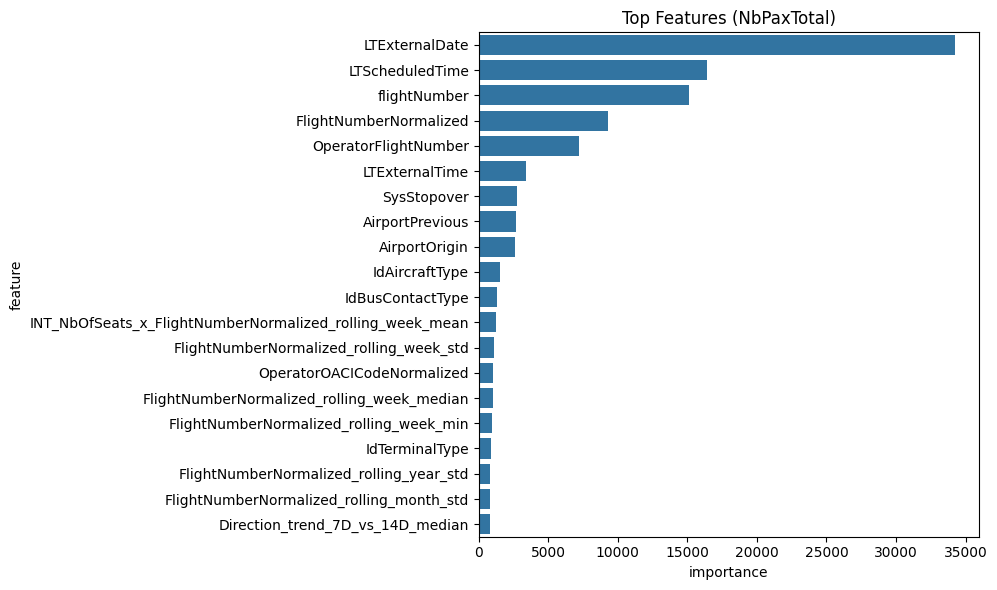

In [18]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

importance.to_csv("features_importances.csv", index=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=importance.head(20))
plt.title("Top Features (NbPaxTotal)")
plt.tight_layout()
plt.show()

#### 2. Prediction VS Reality

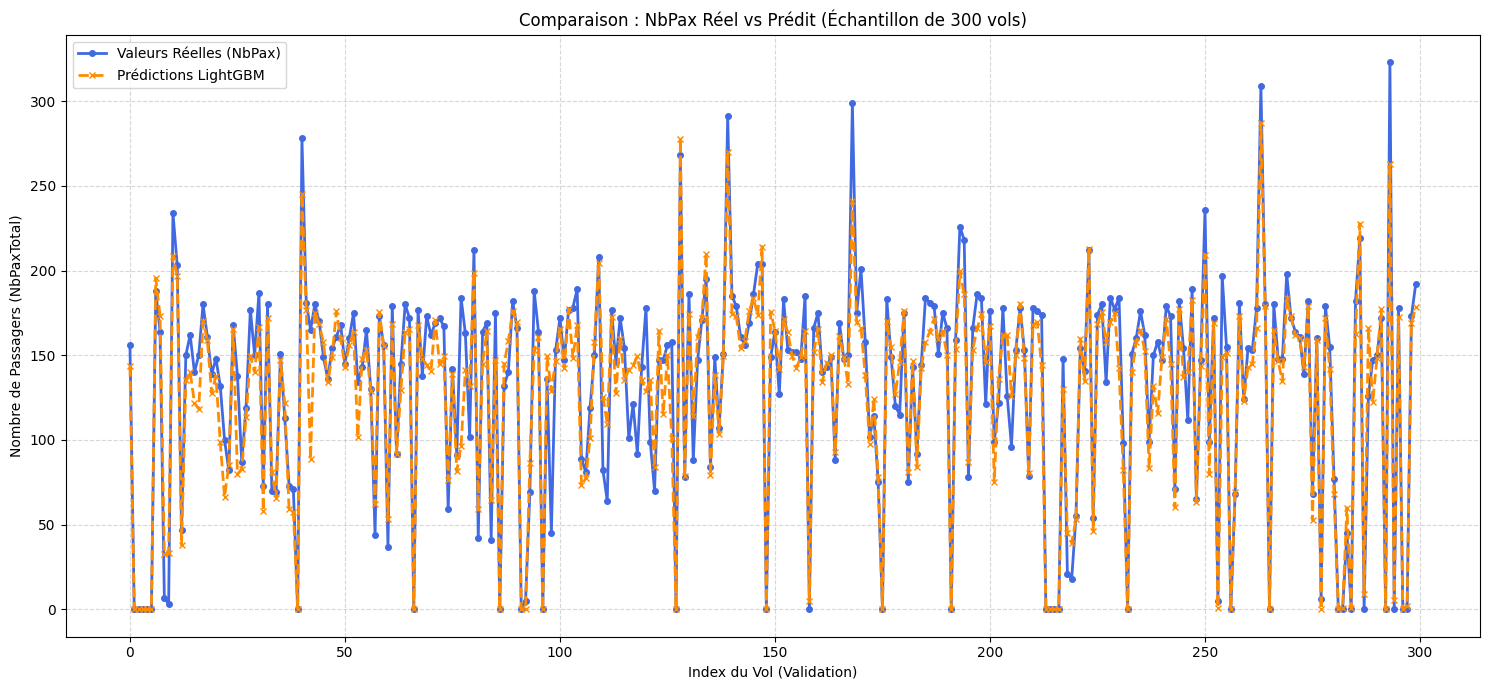

In [19]:
n_sample = 300 
plt.figure(figsize=(15, 7))
plt.plot(y_valid.values[:n_sample], label='Valeurs Réelles (NbPax)', color='royalblue', linewidth=2, marker='o', markersize=4)
plt.plot(predictions[:n_sample], label='Prédictions LightGBM', color='darkorange', linestyle='--', linewidth=2, marker='x', markersize=5)
plt.title(f'Comparaison : NbPax Réel vs Prédit (Échantillon de {n_sample} vols)')
plt.ylabel('Nombre de Passagers (NbPaxTotal)')
plt.xlabel('Index du Vol (Validation)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 3. TOP 10 Errors

In [20]:
analysis_df = valid_df.copy()
analysis_df['Predicted_NbPax'] = predictions
analysis_df['Abs_Error'] = np.abs(analysis_df[TARGET] - analysis_df['Predicted_NbPax'])
top_errors = analysis_df.sort_values(by='Abs_Error', ascending=False).head(10)

columns_to_show = ["IdMovement","FlightNumberNormalized",'LTScheduledDatetime', TARGET, 'Predicted_NbPax', "NbOfSeats", 'Abs_Error']

top_errors_display = top_errors[columns_to_show].copy()
top_errors_display['Predicted_NbPax'] = top_errors_display['Predicted_NbPax'].round(1)
top_errors_display['Abs_Error'] = top_errors_display['Abs_Error'].round(1)

print(top_errors_display.to_string(index=False))

         IdMovement FlightNumberNormalized LTScheduledDatetime  NbPaxTotal  Predicted_NbPax  NbOfSeats  Abs_Error
202601071235009HWNI               WMT06061 2026-01-07 11:30:00         0.0            186.5      239.0      186.5
                NaN               EJU08435 2026-01-04 18:50:00         0.0            174.5      180.0      174.5
                NaN               VOE02533 2026-01-06 00:45:00       171.0              0.0      180.0      171.0
                NaN               BAW00363 2026-01-03 21:45:00       170.0              0.0      180.0      170.0
20260105235000OEIVW               EZY04780 2026-01-06 00:30:00         0.0            169.5      186.0      169.5
202512311848009HWNH               WZZ04394 2025-12-31 19:55:00        57.0            219.9      239.0      162.9
                NaN               DLH01076 2026-01-03 14:15:00       162.0              0.0      180.0      162.0
20260117152700SERTS               NSZ09713 2026-01-17 16:15:00         0.0            16